# Programming Assignment 3: Tabular Q-Learning 

**Objectives:**
1. Implement tabular Q-learning, a reinforcement learning (RL) algorithm, for the two-player strategy game Nim.
2. Implement epsilon-greedy action selection.
3. Train and evaluate against random and rule-based opponents.
4. Explore a SARSA variant as an optional extension.

You will implement the full agent loop and evaluate the learned policy on Nim.

---

**Optional reading:**

1. *Artificial Intelligence: Foundations of Computational Agents* (Poole & Mackworth, 2023). [Chapter 12: Reinforcement Learning](https://artint.info/3e/html/ArtInt3e.Ch12.html)
2. [*Reinforcement Learning: An Introduction*](http://incompleteideas.net/book/the-book-2nd.html) (Sutton & Barto, 2nd ed.). Chapter 6 covers TD-learning and Q-learning

## Assignment Rules
1. Complete only the TODO blocks.
2. Do not change required function signatures. Other parts of the notebook depend on them and may break if they are changed.
3. Do not use external RL libraries; implement all RL algorithms and helper functions from scratch.
4. Keep code deterministic when a seed is fixed (same seed -> same behavior/results).
5. Run cells linearly from top-to-bottom so everything is defined in the correct order.

## Point Breakdown
1. Question 0: Nim setup and utilities (15)
2. Question 1: Core Q-learning functions (40)
3. Question 2: Training loop (25)
4. Question 3: Policy and evaluation (20)

Total graded points: 100

Optional extension: Question 4 SARSA.


## Nim Rules    
    
Nim is a two-player turn-based game played with several piles of objects.    
     
### Game Representation in This Assignment
1. A **state** is the current pile sizes as a tuple of nonnegative integers.
  1. e.g. `state = (1, 3, 5)` means pile 0 has 1 object, pile 1 has 3, pile 2 has 5.
  2. We use a tuple because it's immutable, which makes it safe to use as a dictionary key in the Q-table.
  
1. An **action** is a tuple `(pile_index, remove_count)`.
  1. e.g. `(1, 2)` means "remove 2 objects from pile 1."
  
### Legal Moves
A move is legal if it removes at least 1 object from exactly one non-empty pile.
  1. `pile_index` refers to an existing pile, `remove_count > 0`, and `state[pile_index] > 0`      
    
You can't remove more objects than are in that pile, and you remove from exactly one pile per turn.
  1. so `remove_count <= state[pile_index]` 

### How a Move Changes the State

When you take an action `(i, k)`, only pile `i` changes:
1. before: `state[i]`
2. after:  `state[i] - k`

Example:
1. Start: `(1, 3, 5)`
2. Action: `(2, 4)` → remove 4 from pile 2
3. New state: `(1, 3, 1)`

### Winning Condition
1. The game ends when all piles are empty. The terminal state is `(0, 0, 0)`.
2. The player who takes the last object **wins**.

#### Turn Order: Player 0 always moves first.

**Optional Nim resources:**
1. [Nim overview and winning strategy (Wikipedia)](https://en.wikipedia.org/wiki/Nim)
2. [Play Nim online (Transum)](https://www.transum.org/Software/Nim/)

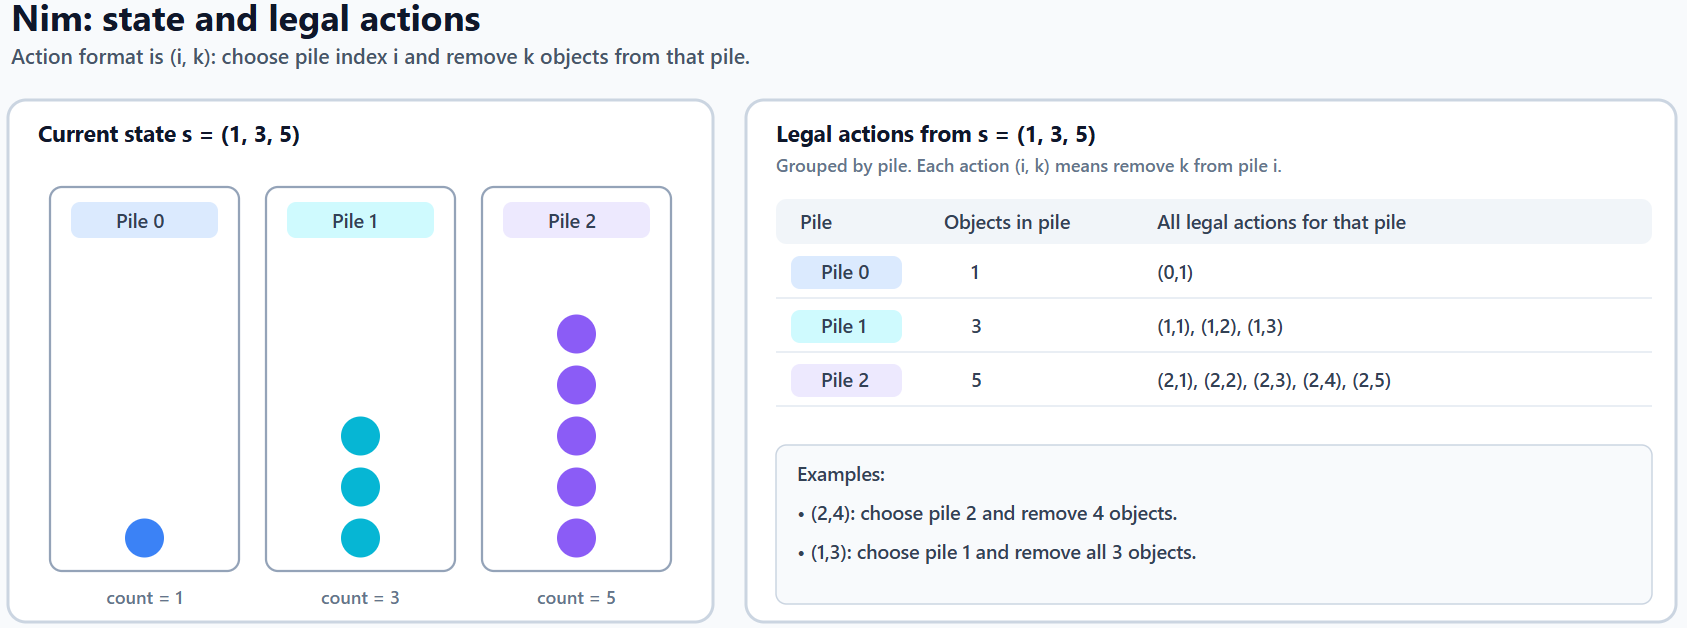

## Setup

In [ ]:
! pip install matplotlib

In [ ]:
import random
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt

Action = Tuple[int, int]  # (pile_index, remove_count)
State = Tuple[int, ...]   # immutable pile counts

INITIAL_STATE: State = (1, 3, 5)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)

set_seed(42)

## Nim State Visualization

Use the next cell to render a Nim state as a bar chart (one bar per pile).

In [ ]:
def style_plots() -> None:
    # Seaborn themes can look cleaner.
    # These styles are applied through matplotlib style names.
    try:
        plt.style.use('seaborn-v0_8-whitegrid')
    except OSError:
        try:
            plt.style.use('seaborn-whitegrid')
        except OSError:
            plt.style.use('default')

    plt.rcParams['figure.figsize'] = (7, 4)
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['legend.fontsize'] = 10

def plot_nim_state(state: State, title: str = 'Nim State') -> None:
    style_plots()
    piles = list(range(len(state)))
    counts = list(state)
    cmap = plt.get_cmap('Blues')
    colors = [cmap(0.45 + 0.45 * (i / max(1, len(state) - 1))) for i in range(len(state))]

    plt.figure()
    bars = plt.bar(piles, counts, color=colors)
    plt.xticks(piles, [f'Pile {i}' for i in piles])
    plt.ylabel('Objects Remaining')
    plt.title(title)
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.05, f'{int(h)}', ha='center', va='bottom')
    plt.ylim(0, max(counts) + 1)
    plt.show()

plot_nim_state(INITIAL_STATE, title='Initial Nim State (1, 3, 5)')


## Opponent Strategies and Turn Handling

Helper functions in the next cell:
1. `next_player`: flips between player 0 and player 1.
2. `random_opponent_action`: picks any legal move uniformly at random.
3. `rule_based_opponent_action`: removes 1 object from the largest non-empty pile.

In [ ]:
def next_player(player: int) -> int:
    return 1 - player

def random_opponent_action(state: State) -> Action:
    actions = legal_actions(state)
    return random.choice(actions)

def rule_based_opponent_action(state: State) -> Action:
    # A simple baseline: choose from the largest non-empty pile, remove 1.
    max_pile = max(range(len(state)), key=lambda i: state[i])
    if state[max_pile] == 0:
        return random_opponent_action(state)
    return (max_pile, 1)

## Question 0: Nim Setup + Utilities (15 points)

Parts (TODO):
- 0.1 Implement `legal_actions`.
  - 5 points
- 0.2 Implement `apply_action`.
  - 5 points
- 0.3 Implement `is_terminal`.
  - 5 points


### Legal Moves
Use the Nim rules above when implementing `legal_actions(state)`.

Include every legal `(pile_index, remove_count)` pair where:
1. `remove_count >= 1`
2. `remove_count <= state[pile_index]`

Return actions in deterministic sorted order by `(pile_index, remove_count)`.

In [ ]:
def legal_actions(state: State) -> List[Action]:
    """
    Return all legal actions for the given state.
    Action format: (pile_index, remove_count), where remove_count >= 1
    and remove_count <= state[pile_index].
    """
    # TODO: build and return all legal actions in deterministic order (sorted by `(pile_index, remove_count)` ascending).
    raise NotImplementedError

### How a Move Changes the State
For `apply_action(state, action)`, update only the selected pile:
1. If `action = (i, k)`, then the next state has `next_state[i] = state[i] - k`.
2. All other piles are unchanged.

Validate legality first, then return the new state as a tuple.

In [ ]:
def apply_action(state: State, action: Action) -> State:
    """
    Apply action to state and return the next state.
    Validate action and raise ValueError for illegal moves.
    """
    # TODO: validate action, apply removal, return new immutable state tuple.
    raise NotImplementedError

### Ending/Winning Condition
For `is_terminal(state)`, return `True` iff all piles are 0.

The move that reaches the terminal state wins.

In [ ]:
def is_terminal(state: State) -> bool:
    """
    Return True iff no objects remain.
    """
    # TODO
    raise NotImplementedError

In [ ]:
# Checkpoint for Question 0
print('Legal actions from (1,3):', legal_actions((1, 3)))
print('Apply action (1,2) to (1,3):', apply_action((1, 3), (1, 2)))
print('Terminal check (0,0,0):', is_terminal((0, 0, 0)))

## Question 1: Core Tabular Q-Learning (40 points)

Use dictionary `Q[(state, action)] -> float` for Q-values.

Parts (TODO):

| Part | Function | Points |
|------|----------|--------|
| 1.1  | `get_q_value` | 5 |
| 1.2  | `best_future_reward` | 10 |
| 1.3  | `choose_action` (epsilon-greedy) | 12 |
| 1.4  | `q_update` | 13 |

### RL Notation Quick Reference

| Symbol | Meaning | In this notebook |
|--------|---------|------------------|
| `s` | current state | tuple of pile sizes, e.g. `(1, 3, 5)` |
| `a` | action | `(pile_index, remove_count)`, e.g. `(2, 4)` |
| `Q(s, a)` | value estimate | stored as `Q[(state, action)]` |
| `r` | immediate reward | `+1` win, `-1` loss, `0` otherwise |
| `s'` | next state | state after transition |
| `alpha` | learning rate | interpolation toward target |
| `gamma` | discount factor | weight on future reward |
| `epsilon` | exploration rate | random-action probability |


### 1.1 Getting a Q-Value

The Q-table is a dictionary mapping `(state, action)` pairs to `float` values:

    Q[(state, action)] --> float

If a pair hasn't been seen yet, default to `0.0`.

In [ ]:
def get_q_value(Q: Dict[Tuple[State, Action], float], state: State, action: Action) -> float:
    """Return Q(state, action), defaulting to 0.0 if missing."""
    # TODO
    raise NotImplementedError

### 1.2 Estimating the Best Future Reward

When the agent reaches a new state `s'` (`s prime`, meaning the next state), we want the best Q-value over all legal actions: `max_a Q(s', a)`.

1. If the state is terminal (no legal actions), return 0.
2. If a state-action pair hasn't been seen, its Q-value is 0.

This function returns the maximum Q-value over legal actions. It does not choose an action.

In [ ]:
def best_future_reward(Q: Dict[Tuple[State, Action], float], state: State) -> float:
    """
    Return max_a Q(state, a).
    If terminal (or no legal actions), return 0.0.
    """
    # TODO
    raise NotImplementedError

### 1.3 Choosing an Action (Exploration vs. Exploitation)

RL has to balance two goals:

1. **Exploitation:** pick the action with the highest known Q-value.
2. **Exploration:** try random actions to discover better strategies.

We use an **epsilon-greedy** strategy:

1. With probability `epsilon`: choose a random legal action.
2. With probability `1 - epsilon`: choose the action with the highest Q-value.

#### Why explore?

Early in training, Q-values are mostly zero and unreliable. If the agent always picks the "best" action, it might never discover that, say, taking from pile 2 is actually a winning move, because it never tried it.

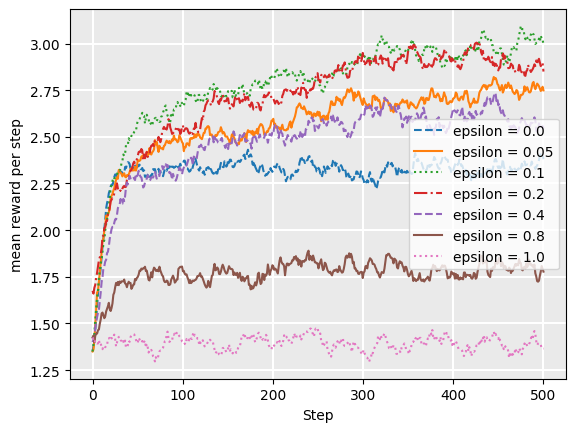

Source: [RL Notes on epsilon greedy exploration](https://gibberblot.github.io/rl-notes/single-agent/multi-armed-bandits.html)

In [ ]:
def choose_action(
    Q: Dict[Tuple[State, Action], float],
    state: State,
    epsilon: float
) -> Action:
    """
    Epsilon-greedy action selection:
    - with probability epsilon: random legal action
    - otherwise: action with highest Q-value (break ties randomly)
    """
    # TODO
    raise NotImplementedError

### 1.4 Updating the Q-Value

This is the core of Q-learning.

After taking action `a` in state `s`, receiving reward `r`, and moving to `s'`, we update:

    Q(s,a) ← Q(s,a) + α * (target − Q(s,a))

where:

    target = reward + γ * max_a' Q(s', a')

1. `reward` = what we just got
2. `γ` (gamma) = how much we value future rewards
3. `max_a' Q(s', a')` = best estimated future outcome
4. `α` (alpha) = learning rate (α=1 replaces the old estimate entirely; α=0 never learns)

#### Example Q-Update

Suppose:
1. Q(s,a) = 0.2
2. reward = 0
3. gamma = 0.9
4. best_future_reward = 0.5
5. alpha = 0.5

Then:

    target = 0 + 0.9 * 0.5 = 0.45
    new Q = 0.2 + 0.5 * (0.45 - 0.2)
          = 0.2 + 0.5 * 0.25
          = 0.325

The Q-value moves slightly toward the new estimate.

In [ ]:
def q_update(
    Q: Dict[Tuple[State, Action], float],
    state: State,
    action: Action,
    reward: float,
    next_state: State,
    alpha: float,
    gamma: float
) -> None:
    """
    Apply Q-learning update:
      Q(s,a) <- Q(s,a) + alpha * (reward + gamma * max_a'Q(s',a') - Q(s,a))
    """
    # TODO
    raise NotImplementedError

In [ ]:
# Checkpoint for Question 1
Q_test = {}
s = (1, 2)
a = (1, 1)
s2 = (1, 1)
print('Initial Q:', get_q_value(Q_test, s, a))
q_update(Q_test, s, a, reward=0.5, next_state=s2, alpha=0.5, gamma=0.9)
print('Updated Q:', get_q_value(Q_test, s, a))

## Question 2: Training Loop (25 points)

Assumptions:
1. Agent (player 0) always goes first.
2. Opponent is `random` or `rule`.
3. Rewards are from player 0's perspective: +1 win, -1 loss, 0 otherwise.
4. You may assume `opponent_action(...)` is only called when the game is **not** terminal.

Parts (TODO):
- 2.1 `train_episode` (13 points)
- 2.2 `train_q_learning` (12 points)

### Update timing in a two player environment
Be careful not to update the wrong `(state, action)` pair. The opponent move sits between two agent decisions, so your update should still correspond to the agent action that started that turn.

High level flow:
1. Choose and apply an agent action.
2. If that move ends the game, do a terminal update and finish.
3. Otherwise apply the opponent move.
4. If that move ends the game, do a terminal update and finish.
5. Otherwise do a nonterminal update for the agent move and continue from the resulting state.

Use your Q learning update helper with the appropriate reward and next state for each case.



### 2.1 Training One Episode

One episode = one full game of Nim from start to finish. Each turn, the agent picks an action (epsilon-greedy), applies it, and updates the Q-table. Rewards are from player 0's perspective: +1 win, -1 loss, 0 otherwise.

In [ ]:
def opponent_action(state: State, mode: str = 'random') -> Action:
    if mode == 'random':
        return random_opponent_action(state)
    if mode == 'rule':
        return rule_based_opponent_action(state)
    raise ValueError(f'Unknown opponent mode: {mode}')

def train_episode(
    Q: Dict[Tuple[State, Action], float],
    alpha: float,
    gamma: float,
    epsilon: float,
    initial_state: State = INITIAL_STATE,
    opponent_mode: str = 'random'
) -> int:
    """
    Run one training episode.
    Return 1 if the agent wins, else 0.
    """
    # TODO:
    # 1) Start from initial_state, agent moves first.
    # 2) On agent move: choose_action -> apply_action.
    # 3) If terminal after agent move: update with reward +1 and return win.
    # 4) Else opponent takes action and transitions.
    # 5) If terminal after opponent move: update agent's last action with reward -1 and return loss.
    # 6) Otherwise update with reward 0 and continue.
    raise NotImplementedError

### 2.2 Training Over Many Episodes

Initialize an empty Q-table, run `train_episode` for the given number of episodes, and record each outcome (1 = win, 0 = loss). Return both the Q-table and the win history.

In [ ]:
def train_q_learning(
    episodes: int,
    alpha: float,
    gamma: float,
    epsilon: float,
    initial_state: State = INITIAL_STATE,
    opponent_mode: str = 'random'
) -> Tuple[Dict[Tuple[State, Action], float], List[float]]:
    """
    Train for multiple episodes and return:
      - learned Q-table
      - list of per-episode outcomes (1 = agent win, 0 = agent loss)
    """
    # TODO
    raise NotImplementedError

In [ ]:
set_seed(42)
# Checkpoint for Question 2 (should work after the training-loop TODOs are complete)
Q_small, win_hist_small = train_q_learning(episodes=200, alpha=0.5, gamma=0.9, epsilon=0.2)
print('Q-table size:', len(Q_small))
print('Last 10 outcomes:', win_hist_small[-10:])

## Question 3: Policy + Evaluation (20 points)

Parts (TODO):
- 3.1 `greedy_policy_action`
  - 7 points
- 3.2 `play_match`
  - 7 points
- 3.3 `evaluate_policy`
  - 6 points


### 3.1 Greedy Policy (No Exploration)

After training, we don't explore anymore. The greedy policy picks: `argmax_a Q(state, a)`

Break ties randomly. Don't use epsilon here.

In [ ]:
def greedy_policy_action(Q: Dict[Tuple[State, Action], float], state: State) -> Action:
    """Choose argmax action under Q for current state (random tie-break)."""
    # TODO
    raise NotImplementedError

### 3.2 Playing One Match

Same structure as a training episode, but with no exploration and no Q updates. Just play the game greedily. Return 1 for a win, 0 for a loss.

In [ ]:
def play_match(
    Q: Dict[Tuple[State, Action], float],
    initial_state: State = INITIAL_STATE,
    opponent_mode: str = 'random'
) -> int:
    """
    Play one game with trained agent policy (greedy, no exploration).
    Return 1 if agent wins, else 0.
    """
    # TODO
    raise NotImplementedError

### 3.3 Evaluating the Policy

Play many matches using `play_match` and return the win rate (wins / total games).

In [ ]:
def evaluate_policy(
    Q: Dict[Tuple[State, Action], float],
    games: int = 500,
    opponent_mode: str = 'random'
) -> float:
    """Return agent win rate over `games` matches."""
    # TODO
    raise NotImplementedError

In [ ]:
set_seed(42)
# Checkpoint for Question 3
wr_random = evaluate_policy(Q_small, games=200, opponent_mode='random')
wr_rule = evaluate_policy(Q_small, games=200, opponent_mode='rule')
print(f'Win rate vs random: {wr_random:.3f}')
print(f'Win rate vs rule:   {wr_rule:.3f}')

## Optional Extension: SARSA

### What is SARSA?

This section is optional and not part of the graded total.

SARSA stands for **S**tate, **A**ction, **R**eward, **S**tate, **A**ction. These are the five values used in each update:

| Symbol | Meaning |
|--------|---------|
| `s`    | Current state |
| `a`    | Action taken |
| `r`    | Reward received |
| `s'`   | Next state |
| `a'`   | Next action actually chosen (not necessarily the best; it is the one the policy *picks*) |

SARSA is an on-policy algorithm: it updates using the action the agent will actually take next, not the theoretically best one.

Q-learning is `off-policy`: it updates from the value of the best next action, even if the current behavior policy would choose a different one.

Q-learning is optimistic. It assumes the agent will always pick the best future action, even while exploring. SARSA is more conservative: if the agent sometimes takes random actions, those suboptimal choices show up in the update target.

### SARSA vs. Q-Learning

|                  | Q-Learning (off-policy)         | SARSA (on-policy)               |
|------------------|---------------------------------|---------------------------------|
| Bootstrap term   | `max_a' Q(s', a')`              | `Q(s', a')`                     |
| What it uses     | Best possible next action       | Next action actually chosen     |
| Exploration effect | Ignored in update             | Reflected in update             |

Parts (TODO):
- 4.1 `sarsa_update`
  - 4 points
- 4.2 `train_episode_sarsa`
  - 6 points


### 4.1 The SARSA Update Rule

Same structure as Q-learning, but it uses `Q(s', a')`, the Q-value of the action *actually chosen next*, instead of `max_a' Q(s', a')`:

    Q(s, a) ← Q(s, a) + α * (target − Q(s, a))

where:

    target = r + γ * Q(s', a')

**Terminal case:** If the episode ends after the agent's move, there's no next action, so the bootstrap term is 0: `target = r`

#### Example SARSA Update

Suppose:
1. Q(s, a)   = 0.2
2. reward    = 0
3. gamma     = 0.9
4. Q(s', a') = 0.5
5. alpha     = 0.5

Then:

    target  = 0 + 0.9 * 0.5 = 0.45
    new Q   = 0.2 + 0.5 * (0.45 − 0.2)
            = 0.2 + 0.125
            = 0.325

In [ ]:
def sarsa_update(
    Q: Dict[Tuple[State, Action], float],
    state: State,
    action: Action,
    reward: float,
    next_state: State,
    next_action: Optional[Action],
    alpha: float,
    gamma: float
) -> None:
    """
    SARSA update:
      Q(s,a) <- Q(s,a) + alpha * (reward + gamma * Q(s',a') - Q(s,a))
    If next_action is None (terminal), use bootstrap term 0.
    """
    # TODO
    raise NotImplementedError

### 4.2 Training One SARSA Episode

Use the same game flow as `train_episode`, with one key change:

1. SARSA bootstraps from the next action actually chosen by the policy, so the update target uses `Q(s', a')`.

High level workflow:
1. Start each episode by choosing an initial action from the initial state.
2. Repeat the game turn flow (agent move, then opponent/environment move).
3. If a terminal state is reached, do one terminal update with `next_action=None` and end the episode.
4. Otherwise, choose the next action from the new state, update with that action, and continue.

**Loop sketch (high level):**

```
initialize state and first action
repeat until terminal:
    execute one full turn
    if terminal transition:
        perform terminal SARSA update
        stop
    choose next action from next state
    perform SARSA update using that next action
    advance to the next (state, action)
```

Be careful to update the `(state, action)` that produced the transition.


In [ ]:
def train_episode_sarsa(
    Q: Dict[Tuple[State, Action], float],
    alpha: float,
    gamma: float,
    epsilon: float,
    initial_state: State = INITIAL_STATE,
    opponent_mode: str = 'random'
) -> int:
    """Train one episode with SARSA (agent still plays against selected opponent)."""
    # TODO
    raise NotImplementedError

In [ ]:
# Checkpoint for Question 4 (optional extension)
Q_sarsa = {}
outcome = train_episode_sarsa(Q_sarsa, alpha=0.5, gamma=0.9, epsilon=0.2)
print('SARSA episode outcome:', outcome)
print('SARSA Q-table size:', len(Q_sarsa))

## Submission Checklist
1. [ ] All TODOs are implemented
2. [ ] Notebook runs end-to-end without signature changes
3. [ ] Question 3 eval smoke-check cells run
4. [ ] Optional extension: Question 4 SARSA checkpoint cell runs